In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('train.xlsx')

In [46]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
!pip install openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,Total Sales by Region,NaN,NaN,Total Sales by Category,NaN,NaN,Total Sales by Sub Category,NaN,NaN,Sales Trend Over Time,NaN
1,Row Labels,Sum of Sales,NaN,Row Labels,Sum of Sales,NaN,Row Labels,Sum of Sales,NaN,Row Labels,Sum of Sales
2,Central,492646.9132,NaN,Furniture,728658.5757,NaN,Phones,327782.448,NaN,2018,722052.0192
3,East,669518.726,NaN,Office Supplies,705422.334,NaN,Chairs,322822.731,NaN,2017,600192.55
4,South,389151.459,NaN,Technology,827455.873,NaN,Storage,219343.392,NaN,2015,479856.2081


In [49]:
import openpyxl
wb = openpyxl.load_workbook('train.xlsx', read_only=True)
print(wb.sheetnames)

['REPORT', 'DASHBOARD', 'KPI', 'train (2)', 'train']


In [50]:
df = pd.read_excel('train.xlsx', sheet_name='train (2)')
df.head()

,Row ID,Order ID,Order Date,ORDER YEAR,Ship Date,Ship YEAR,Ship Mode,Customer ID,Customer Name,Segment,...,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Unnamed: 20,year
0,1,CA-2017-152156,2017-11-08,2017,2017-11-11,2017,Second Class,CG-12520,Claire Gute,Consumer,...,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,NaN,2017
1,2,CA-2017-152156,2017-11-08,2017,2017-11-11,2017,Second Class,CG-12520,Claire Gute,Consumer,...,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,NaN,2017
2,3,CA-2017-138688,2017-06-12,2017,2017-06-16,2017,Second Class,DV-13045,Darrin Van Huff,Corporate,...,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,NaN,2017
3,4,US-2016-108966,2016-10-11,2016,2016-10-18,2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,...,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,NaN,2016
4,5,US-2016-108966,2016-10-11,2016,2016-10-18,2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,...,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,NaN,2016


In [51]:
print(df.shape)
df.info()

(9800, 22)
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3    ORDER YEAR    9800 non-null   int64         
 4   Ship Date      9800 non-null   datetime64[us]
 5   Ship YEAR      9800 non-null   int64         
 6   Ship Mode      9800 non-null   str           
 7   Customer ID    9800 non-null   str           
 8   Customer Name  9800 non-null   str           
 9   Segment        9800 non-null   str           
 10  Country        9800 non-null   str           
 11  City           9800 non-null   str           
 12  State          9800 non-null   str           
 13  Postal Code    9789 non-null   float64       
 14  Region         9800 non-null   str           
 15  Product ID     9800 n

In [52]:
df.isnull().sum()

Row ID              0
Order ID            0
Order Date          0
 ORDER YEAR         0
Ship Date           0
Ship YEAR           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Unnamed: 20      9800
year                0
dtype: int64

In [53]:
df.describe()

,Row ID,Order Date,ORDER YEAR,Ship Date,Ship YEAR,Postal Code,Sales,Unnamed: 20,year
count,9800.000000,9800,9800.000000,9800,9800.000000,9789.000000,9800.000000,0.0,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2016.724184,2017-04-21 19:45:12.489796,2016.739388,55273.322403,230.769059,NaN,2016.724184
min,1.000000,2015-01-03 00:00:00,2015.000000,2015-01-04 00:00:00,2015.000000,1040.000000,0.444000,NaN,2015.000000
25%,2450.750000,2016-05-24 00:00:00,2016.000000,2016-05-08 00:00:00,2016.000000,23223.000000,17.248000,NaN,2016.000000
50%,4900.500000,2017-06-26 00:00:00,2017.000000,2017-06-12 00:00:00,2017.000000,58103.000000,54.490000,NaN,2017.000000
75%,7350.250000,2018-05-15 00:00:00,2018.000000,2018-05-02 00:00:00,2018.000000,90008.000000,210.605000,NaN,2018.000000
max,9800.000000,2018-12-30 00:00:00,2018.000000,2019-05-01 00:00:00,2019.000000,99301.000000,22638.480000,NaN,2018.000000
std,2829.160653,NaN,1.123984,NaN,1.126837,32041.223413,626.651875,NaN,1.123984


In [54]:
df.columns = df.columns.str.strip()

In [55]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'ORDER YEAR',
 'Ship Date',
 'Ship YEAR',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Unnamed: 20',
 'year']

In [56]:
df[['Order Date', 'ORDER YEAR', 'Ship Date', 'Ship YEAR', 'year']].head(10)

,Order Date,ORDER YEAR,Ship Date,Ship YEAR,year
0,2017-11-08,2017,2017-11-11,2017,2017
1,2017-11-08,2017,2017-11-11,2017,2017
2,2017-06-12,2017,2017-06-16,2017,2017
3,2016-10-11,2016,2016-10-18,2016,2016
4,2016-10-11,2016,2016-10-18,2016,2016
5,2015-06-09,2015,2015-06-14,2015,2015
6,2015-06-09,2015,2015-06-14,2015,2015
7,2015-06-09,2015,2015-06-14,2015,2015
8,2015-06-09,2015,2015-06-14,2015,2015
9,2015-06-09,2015,2015-06-14,2015,2015


In [57]:
df[df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,ORDER YEAR,Ship Date,Ship YEAR,Ship Mode,Customer ID,Customer Name,Segment,...,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Unnamed: 20,year
2234,2235,CA-2018-104066,2018-12-05,2018,2018-10-12,2018,Standard Class,QJ-19255,Quincy Jones,Corporate,...,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,NaN,2018
5274,5275,CA-2016-162887,2016-11-07,2016,2016-09-11,2016,Second Class,SV-20785,Stewart Visinsky,Consumer,...,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,NaN,2016
8798,8799,US-2017-150140,2017-04-06,2017,2017-10-04,2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,...,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,NaN,2017
9146,9147,US-2017-165505,2017-01-23,2017,2017-01-27,2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,...,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,NaN,2017
9147,9148,US-2017-165505,2017-01-23,2017,2017-01-27,2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,...,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,NaN,2017
9148,9149,US-2017-165505,2017-01-23,2017,2017-01-27,2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,...,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,NaN,2017
9386,9387,US-2018-127292,2018-01-19,2018,2018-01-23,2018,Standard Class,RM-19375,Raymond Messe,Consumer,...,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,NaN,2018
9387,9388,US-2018-127292,2018-01-19,2018,2018-01-23,2018,Standard Class,RM-19375,Raymond Messe,Consumer,...,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,NaN,2018
9388,9389,US-2018-127292,2018-01-19,2018,2018-01-23,2018,Standard Class,RM-19375,Raymond Messe,Consumer,...,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,NaN,2018
9389,9390,US-2018-127292,2018-01-19,2018,2018-01-23,2018,Standard Class,RM-19375,Raymond Messe,Consumer,...,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,NaN,2018


In [58]:
df['Postal Code'] = df['Postal Code'].fillna(5401)

In [59]:
df = df.drop(columns=['ORDER YEAR', 'Ship YEAR', 'year'])

In [60]:
df.isnull().sum()

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Unnamed: 20      9800
dtype: int64

In [61]:
#Descriptive statistics for Sales
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [62]:
df['Sales'].mode()

0    12.96
Name: Sales, dtype: float64

In [63]:
#Time Series Trend
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales.head()

Order Month
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64

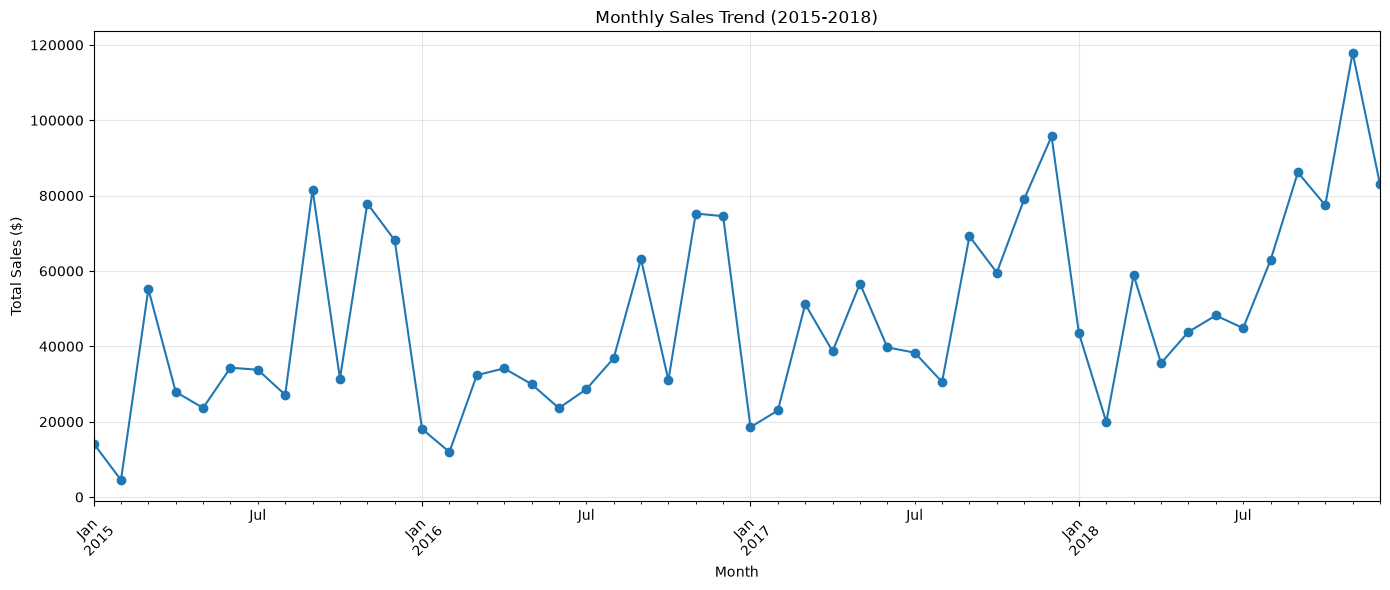

In [64]:
#monthly sales trend
plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
Observation: Monthly sales show no strong long-term growth trend, fluctuating mostly 
between $20K–$80K. However, a clear seasonal pattern emerges — sales consistently spike 
every December, suggesting a holiday shopping surge. 2018 shows the strongest December 
peak (~$120K) of all four years.

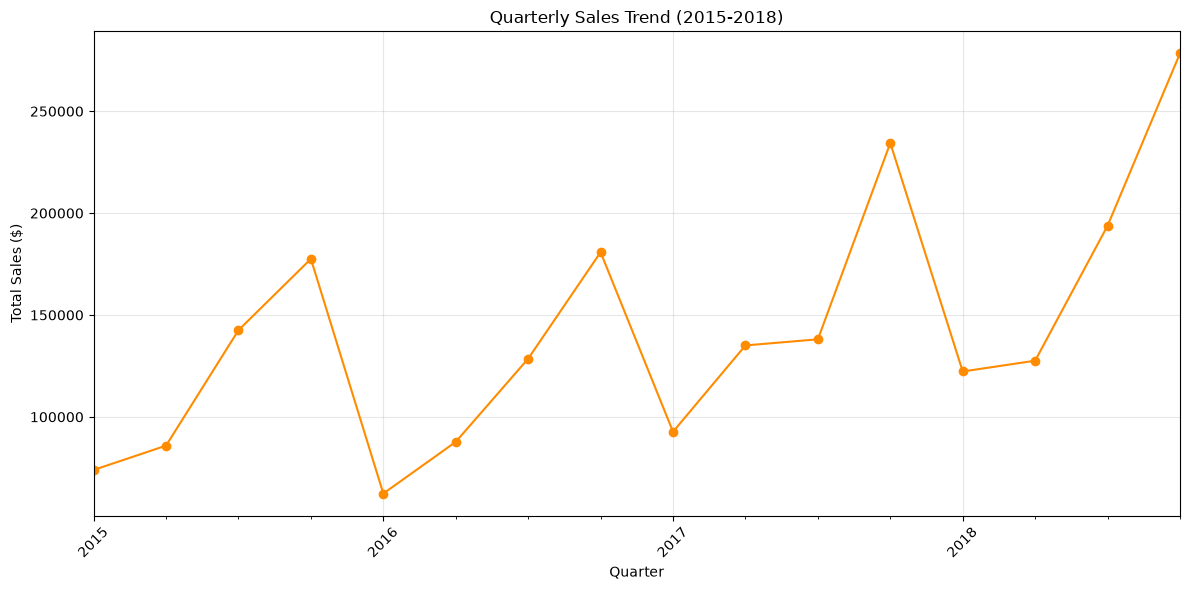

In [67]:
#Quarterly sales trend
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

plt.figure(figsize=(12,6))
quarterly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Quarterly Sales Trend (2015-2018)')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()


In [ ]:
Observation: The quarterly view reveals two things the monthly chart obscured: 
(1) a consistent seasonal pattern where sales dip in Q1 and peak sharply in Q4 every single year, and 
(2) a genuine year-over-year growth trend, with each year's Q4 peak higher than the previous year's.

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64


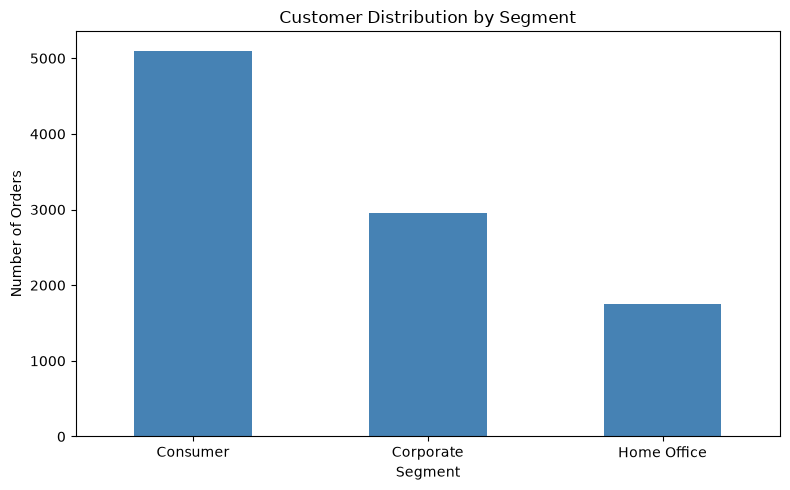

In [68]:
#No Personal Customer demographics
segment_counts = df['Segment'].value_counts()
print(segment_counts)

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar', color='steelblue')
plt.title('Customer Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64


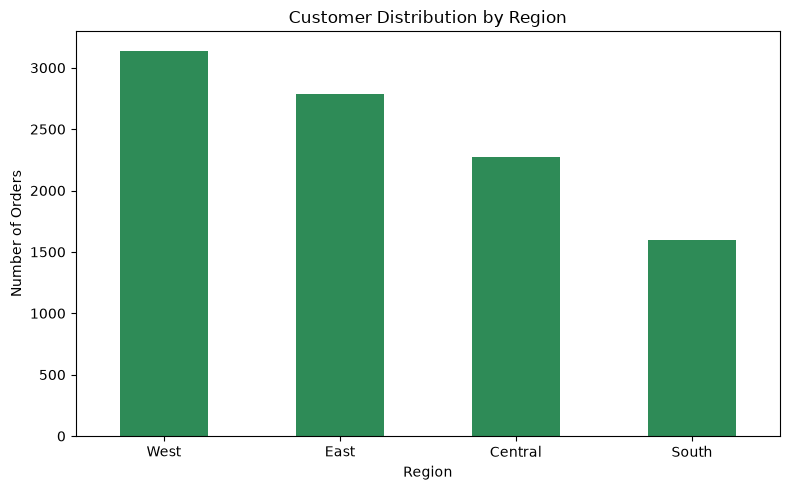

In [69]:
region_counts = df['Region'].value_counts()
print(region_counts)

plt.figure(figsize=(8,5))
region_counts.plot(kind='bar', color='seagreen')
plt.title('Customer Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
Observation: Since this dataset doesn't include personal demographic fields like age 
or gender, we analyzed Customer Segment and Region as proxies for customer distribution. 

Consumer segment dominates order volume (5,101 orders, 52%), followed by Corporate 
(2,953) and Home Office (1,746) — expected, since individual consumers naturally place 
more frequent, smaller orders than businesses.

By region, West leads with 3,140 orders, followed by East (2,785), Central (2,277), and 
South (1,598). The spread is reasonably even and reflects natural population/business 
density across US regions, with no major red flags.

In [70]:
#Product Analysis
#Top 10 best-selling products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


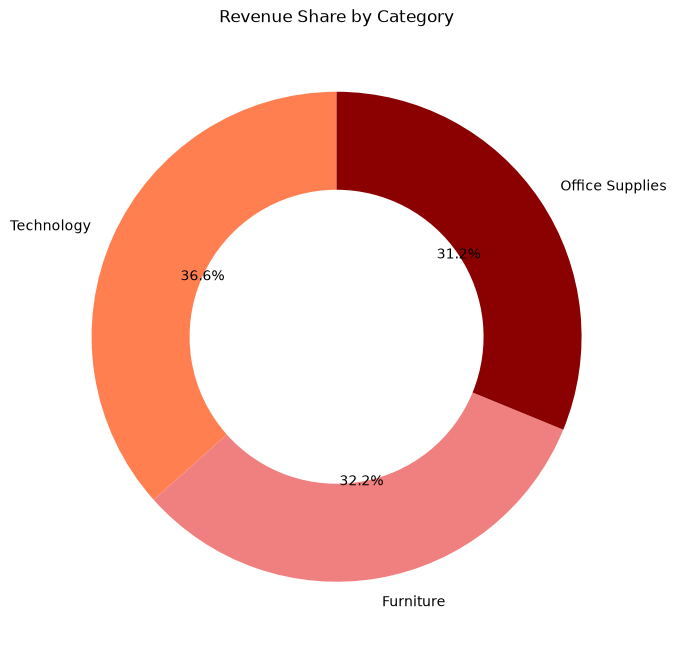

In [71]:
#Revenue by Category
colors = ['coral', 'lightcoral', 'darkred']

plt.figure(figsize=(7,7))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, 
        wedgeprops={'width': 0.4})
plt.title('Revenue Share by Category')
plt.tight_layout()
plt.show()

In [ ]:
Observation: Revenue is distributed across Technology, Furniture, and Office 
Supplies categories, with the top 10 products list showing which individual items drive 
the most revenue. 

                  Sales  Shipping Days  Postal Code
Sales          1.000000      -0.003296    -0.025588
Shipping Days -0.003296       1.000000     0.001969
Postal Code   -0.025588       0.001969     1.000000


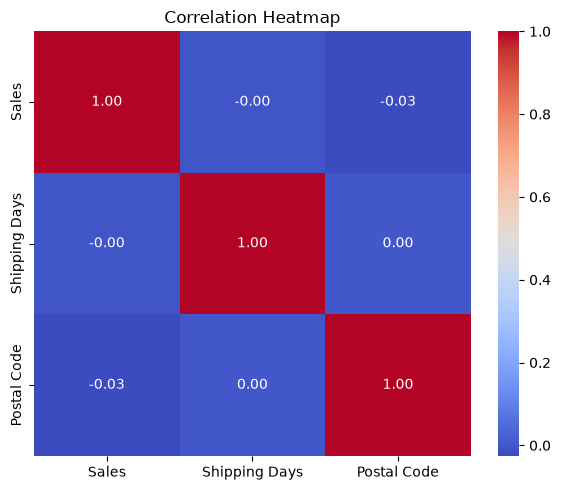

In [72]:
#Correlation heatmap
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

numeric_cols = df[['Sales', 'Shipping Days', 'Postal Code']]
corr_matrix = numeric_cols.corr()
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
Observation: The correlation heatmap shows negligible correlation (all values near 
0) between Sales, Shipping Days, and Postal Code. This suggests shipping duration and 
geographic location have no meaningful relationship with order value — for example, 
large orders don't take systematically longer to ship, and location doesn't predict 
spending. Note: this dataset has limited numeric columns (no Profit, Quantity, or 
Discount), so the heatmap's scope is naturally narrow.

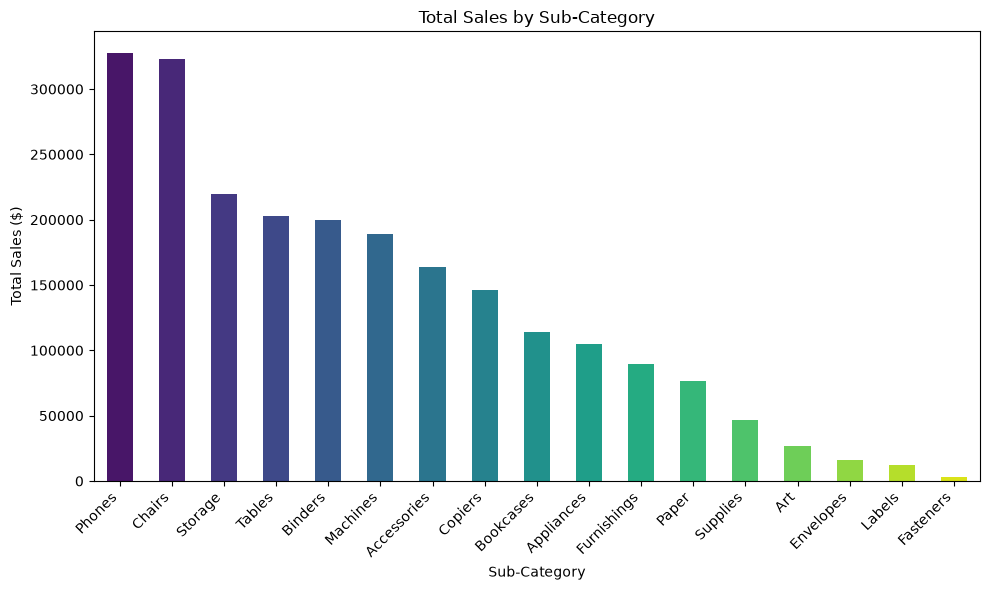

In [73]:
#Extra Visualization
#Sales by Sub-Category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
subcat_sales.plot(kind='bar', color=sns.color_palette('viridis', len(subcat_sales)))
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
Observation: Phones and Chairs are the clear revenue leaders by sub-category (~$320K 
each), notably outperforming other high-volume categories like Storage, Tables, and 
Binders. This is a non-obvious insight — Technology's strength is driven almost entirely 
by Phones rather than being spread evenly across tech products, suggesting phone 
accessories/sales could be a strategic focus area.

In [ ]:
Conclusion & Business Recommendations

1. Prepare inventory and staffing for Q4 demand surges. Sales consistently spike 
every December across all four years, with 2018's peak being the highest yet. The 
business should scale up stock levels and staffing ahead of Q4 rather than reacting 
after demand hits.

2. Investigate the Q1 slump. Every year shows a sharp sales drop in Q1 following the 
Q4 peak. A targeted January/February promotion or loyalty campaign could help smooth out 
this seasonal dip and retain post-holiday momentum.

3. Double down on the Consumer segment and top-performing sub-categories. Consumer 
orders make up over half of all transactions (52%), and Phones and Chairs lead sub-
category sales by a wide margin. Marketing spend and product development should 
prioritize these proven winners rather than spreading resources evenly across all 
segments and categories.

In [74]:
df.to_csv('cleaned_superstore_sales.csv', index=False)